In [1]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix



In [4]:
df = pd.read_csv(
    "/content/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None
)
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


Extract text and labels

In [5]:
# Column 5 → tweet text
texts = df[5].astype(str).tolist()

# Column 0 → sentiment (0 = negative, 4 = positive)
labels = df[0].tolist()


Convert sentiment labels to binary

In [6]:
# Convert 4 to 1 (positive sentiment)
labels = [1 if y == 4 else 0 for y in labels]


Text preprocessing

In [7]:
clean_texts = []

for text in texts:
    text = text.lower()                          # lowercase
    text = re.sub(r"http\S+", " ", text)         # remove URLs
    text = re.sub(r"@\w+", " ", text)            # remove mentions
    text = re.sub(r"#", " ", text)               # remove hashtag symbol
    text = re.sub(r"\d+", " ", text)             # remove numbers
    text = re.sub(r"[^a-z\s]", " ", text)        # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    clean_texts.append(text)


Split into training and testing sets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    clean_texts, labels, test_size=0.2, random_state=42
)


Convert text into TF-IDF features

In [10]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


Train Naive Bayes model

In [11]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

In [12]:
predictions = model.predict(X_test_vec)

# Accuracy
print("Accuracy:", accuracy_score(y_test, predictions))

# Classification report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    predictions,
    target_names=["Negative", "Positive"]
))


Accuracy: 0.753671875

Classification Report:

              precision    recall  f1-score   support

    Negative       0.75      0.76      0.75    159494
    Positive       0.76      0.75      0.75    160506

    accuracy                           0.75    320000
   macro avg       0.75      0.75      0.75    320000
weighted avg       0.75      0.75      0.75    320000



Confusion Matrix


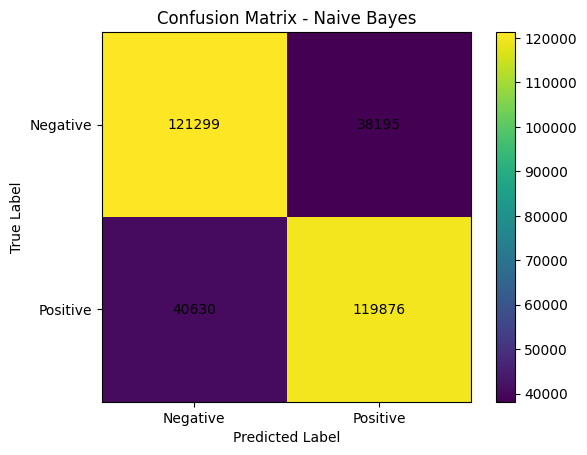

In [13]:
cm = confusion_matrix(y_test, predictions)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Naive Bayes")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

# Add values manually (no for loop)
plt.text(0, 0, cm[0, 0], ha="center", va="center")
plt.text(1, 0, cm[0, 1], ha="center", va="center")
plt.text(0, 1, cm[1, 0], ha="center", va="center")
plt.text(1, 1, cm[1, 1], ha="center", va="center")

plt.show()


Graphs and Visualization

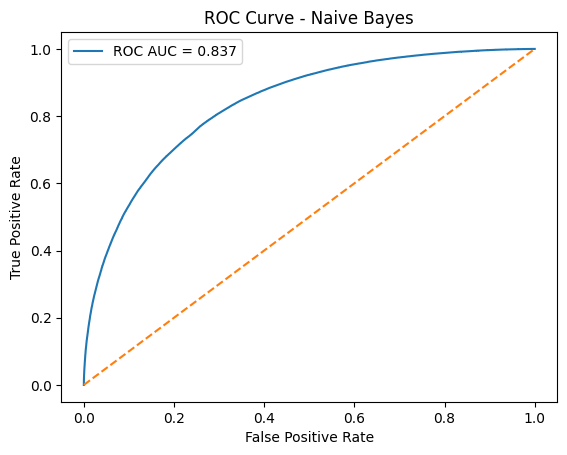

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Probability of Positive class (class 1)
y_score = model.predict_proba(X_test_vec)[:, 1]

# ROC values
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label="ROC AUC = " + str(round(roc_auc, 3)))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.show()


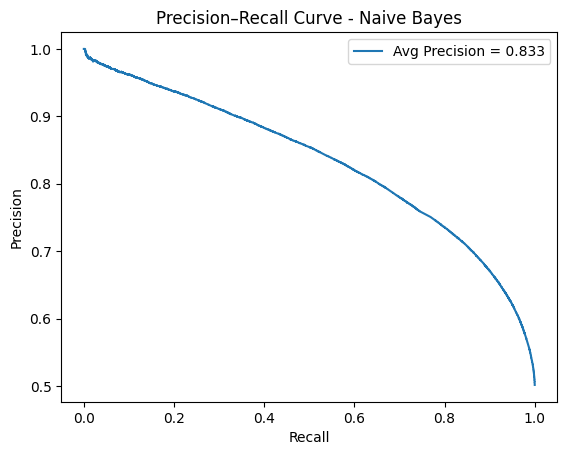

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall values
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_prec = average_precision_score(y_test, y_score)

# Plot PR curve
plt.figure()
plt.plot(recall, precision, label="Avg Precision = " + str(round(avg_prec, 3)))
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Naive Bayes")
plt.legend()
plt.show()


Logistic Regression


In [25]:
log_model = LogisticRegression(max_iter=4000)
log_model.fit(X_train_vec, y_train)


LogisticRegression(max_iter=4000)

In [26]:
log_predictions = log_model.predict(X_test_vec)


In [27]:
print("Accuracy:", accuracy_score(y_test, log_predictions))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    log_predictions,
    target_names=["Negative", "Positive"]
))


Accuracy: 0.768709375

Classification Report:

              precision    recall  f1-score   support

    Negative       0.78      0.74      0.76    159494
    Positive       0.76      0.80      0.78    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



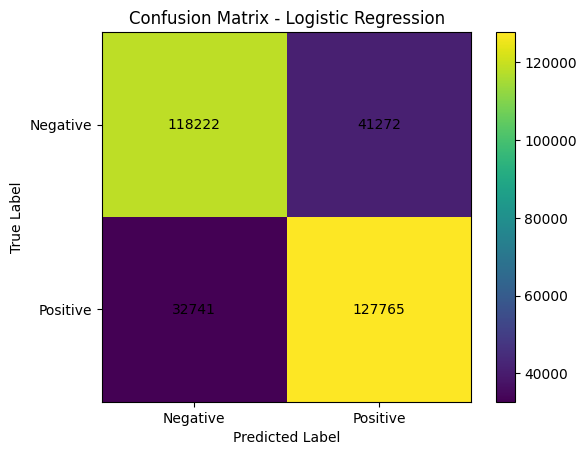

In [28]:
cm_log = confusion_matrix(y_test, log_predictions)

plt.figure()
plt.imshow(cm_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

plt.text(0, 0, cm_log[0, 0], ha="center", va="center")
plt.text(1, 0, cm_log[0, 1], ha="center", va="center")
plt.text(0, 1, cm_log[1, 0], ha="center", va="center")
plt.text(1, 1, cm_log[1, 1], ha="center", va="center")

plt.show()


	Graphs and Visualization

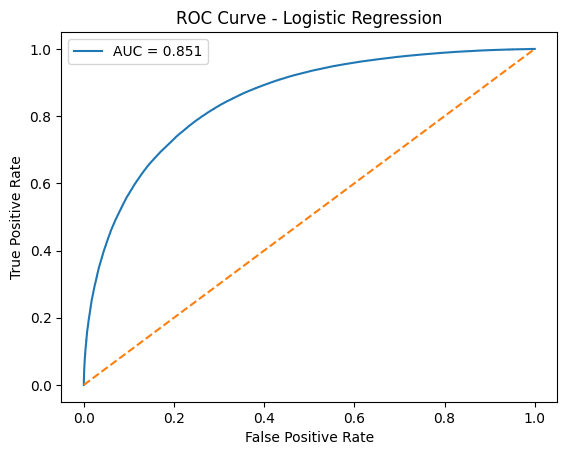

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability scores for positive class
log_probs = log_model.predict_proba(X_test_vec)[:, 1]

# ROC curve values
fpr, tpr, _ = roc_curve(y_test, log_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc, 3)))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


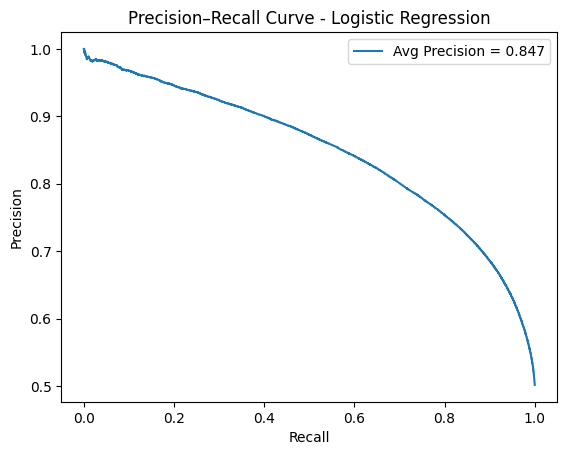

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision–Recall values
precision, recall, _ = precision_recall_curve(y_test, log_probs)
avg_precision = average_precision_score(y_test, log_probs)

# Plot Precision–Recall curve
plt.figure()
plt.plot(recall, precision, label="Avg Precision = " + str(round(avg_precision, 3)))
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Logistic Regression")
plt.legend()
plt.show()


SVM

In [22]:
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)


LinearSVC()

In [34]:
svm_predictions = svm_model.predict(X_test_vec)
svm_scores = svm_model.decision_function(X_test_vec)


In [24]:
print("Accuracy:", accuracy_score(y_test, svm_predictions))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    svm_predictions,
    target_names=["Negative", "Positive"]
))


Accuracy: 0.767859375

Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.74      0.76    159494
    Positive       0.75      0.80      0.78    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



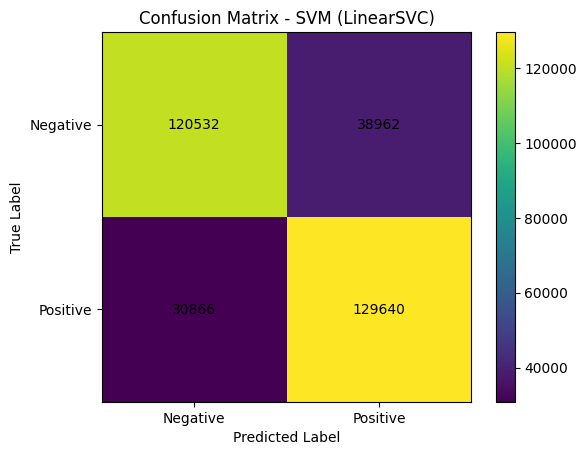

In [ ]:
cm_svm = confusion_matrix(y_test, svm_predictions)

plt.figure()
plt.imshow(cm_svm)
plt.title("Confusion Matrix - SVM (LinearSVC)")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

plt.text(0, 0, cm_svm[0, 0], ha="center", va="center")
plt.text(1, 0, cm_svm[0, 1], ha="center", va="center")
plt.text(0, 1, cm_svm[1, 0], ha="center", va="center")
plt.text(1, 1, cm_svm[1, 1], ha="center", va="center")

plt.show()


Graphs and Visualization

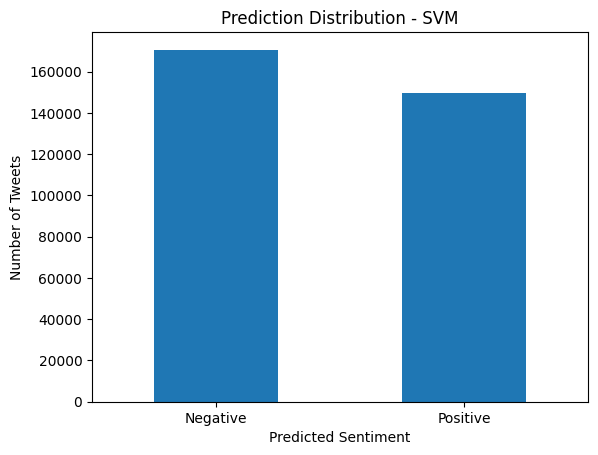

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Count predicted labels
pred_counts = pd.Series(svm_predictions).value_counts()

# Plot bar chart
plt.figure()
pred_counts.plot(kind="bar")
plt.xticks([0, 1], ["Negative", "Positive"], rotation=0)
plt.xlabel("Predicted Sentiment")
plt.ylabel("Number of Tweets")
plt.title("Prediction Distribution - SVM")
plt.show()


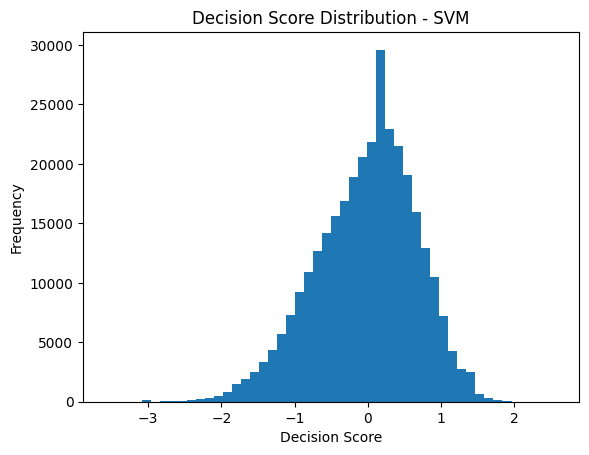

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(svm_scores, bins=50)
plt.xlabel("Decision Score")
plt.ylabel("Frequency")
plt.title("Decision Score Distribution - SVM")
plt.show()


Model In Action

In [41]:
# New tweet (input)
new_texts = ["The service was excellent and I am very happy"]

# Clean it using the SAME cleaning style as above
clean_new_texts = []

for text in new_texts:
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    clean_new_texts.append(text)

# Convert to TF-IDF using the already-trained vectorizer
new_vec = vectorizer.transform(clean_new_texts)

# Predict using the trained SVM model
svm_result = svm_model.predict(new_vec)

# Show result
label_map = {0: "Negative", 1: "Positive"}
print("Tweet:", new_texts[0])
print("Predicted Sentiment (SVM):", label_map[svm_result[0]])
svm_score = svm_model.decision_function(new_vec)
print("SVM Decision Score:", svm_score[0])


Tweet: The service was excellent and I am very happy
Predicted Sentiment (SVM): Positive
SVM Decision Score: 1.0167804396534745
